In [1]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

from GradCAM import GradCAM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [2]:
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
CUDA version: 12.1
GPU count: 1
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
torch.__version__

'2.5.1+cu121'

In [5]:
target_layer = model.layer4[-1]
explainer = GradCAM(model, target_layer)

In [2]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    tensor = transform(img).unsqueeze(0)
    return img, tensor

In [6]:
img, input_tensor = load_image("../Pictures/Indian_Cobra.jpg")

input_tensor = input_tensor.to(device)

cam, output = explainer.explain(input_tensor)

# Softmax
probs = torch.softmax(output, dim=1)
confidence, pred_class = torch.max(probs, dim=1)

confidence = confidence.item()
pred_class = pred_class.item()

# ImageNet labels
weights = models.ResNet50_Weights.DEFAULT
class_names = weights.meta["categories"]
label = class_names[pred_class]

print(f"Predicted class: {label}")
print(f"Confidence: {confidence:.4f}")

cam = cam.squeeze().cpu().numpy()

Predicted class: Indian cobra
Confidence: 1.0000


In [7]:
import torch.nn.functional as F
import numpy as np

img_np = np.array(img)

cam_tensor = torch.tensor(cam).unsqueeze(0).unsqueeze(0)

cam_resized = F.interpolate(
    cam_tensor,
    size=(img_np.shape[0], img_np.shape[1]),
    mode="bilinear",
    align_corners=False
)

cam_resized = cam_resized.squeeze().numpy()


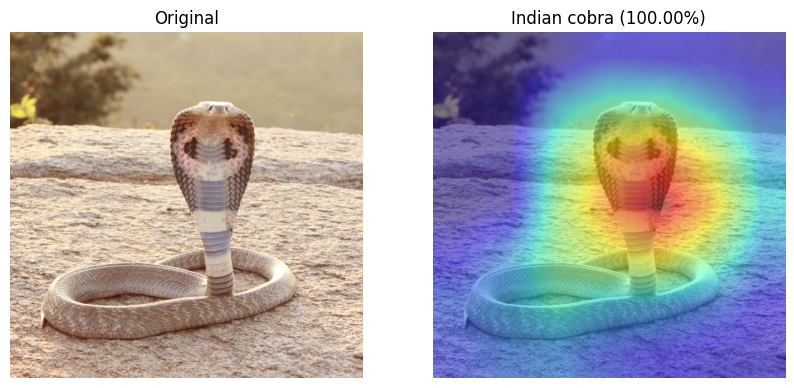

In [8]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_np)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_np)
plt.imshow(cam_resized, cmap='jet', alpha=0.5)
plt.title(f"{label} ({confidence:.2%})")
plt.axis("off")

plt.show()